# Урок 1. Введение: что такое градиентный бустинг

**Интерактивная версия:** `lessons/lesson_1/web/index.html`

После урока вы сможете:
- объяснить идею бустинга: сумма простых моделей, каждая исправляет остатки суммы предыдущих;
- выполнить вручную два шага бустинга на пнях и объяснить роль темпа обучения $\nu$;
- объяснить, почему бустинг «градиентный», и сравнить его с бэггингом;
- обучить первую модель в scikit-learn и в учебной библиотеке `gbcourse`.

План ноутбука — тот же, что у веб-урока, от простого к сложному:
1. Бустинг одного числа: остаток умножается на $(1-\nu)$ за шаг.
2. Бустинг вручную на шести квартирах: остатки → пень → обновление.
3. Слабый ученик и сила суммы: пень, глубокое дерево, бэггинг, бустинг.
4. Бустинг на 60 точках шаг за шагом.
5. Почему «градиентный»: квадратичные и абсолютные потери на данных с выбросами.
6. Весь алгоритм в десяти строках — и сверка с scikit-learn.

In [1]:
# Подключаем учебную библиотеку курса gbcourse (папка shared/python в корне курса)
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np

from gbcourse import BaggingTrees, GBRegressor, RegressionTree, datasets, style
from gbcourse.metrics import mse
from gbcourse.plotting import plot_boosting_step, plot_data, plot_stages, plot_truth, use_course_style

use_course_style()

## 1. Бустинг одного числа

Модель — одно число $F$. Цель — $y = 10$, старт $F_0 = 0$. На каждом шаге «слабый ученик» сообщает
остаток $r = y - F$, а мы прибавляем лишь его долю $\nu$ (темп обучения):

$$F_m = F_{m-1} + \nu \, (y - F_{m-1}) \quad\Rightarrow\quad r_m = (1-\nu)\, r_{m-1} = (1-\nu)^m\, r_0.$$

In [2]:
def boost_a_number(y: float, nu: float, steps: int) -> np.ndarray:
    """Прогнозы F_0, F_1, …, F_steps «бустинга одного числа»."""
    F = [0.0]
    for _ in range(steps):
        r = y - F[-1]  # остаток: сколько осталось до цели
        F.append(F[-1] + nu * r)  # «ученик» знает остаток точно, берём его долю ν
    return np.array(F)


F = boost_a_number(10, 0.5, 5)
print("ν = 0.5, прогнозы:", F)
print("остатки:          ", 10 - F)
print("формула (1-ν)^m·10:", 0.5 ** np.arange(6) * 10)

ν = 0.5, прогнозы: [0.     5.     7.5    8.75   9.375  9.6875]
остатки:           [10.      5.      2.5     1.25    0.625   0.3125]
формула (1-ν)^m·10: [10.      5.      2.5     1.25    0.625   0.3125]


Три режима из одной формулы: $0<\nu<1$ — монотонно, $1<\nu<2$ — с перелётами, $\nu \ge 2$ — расходимость.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


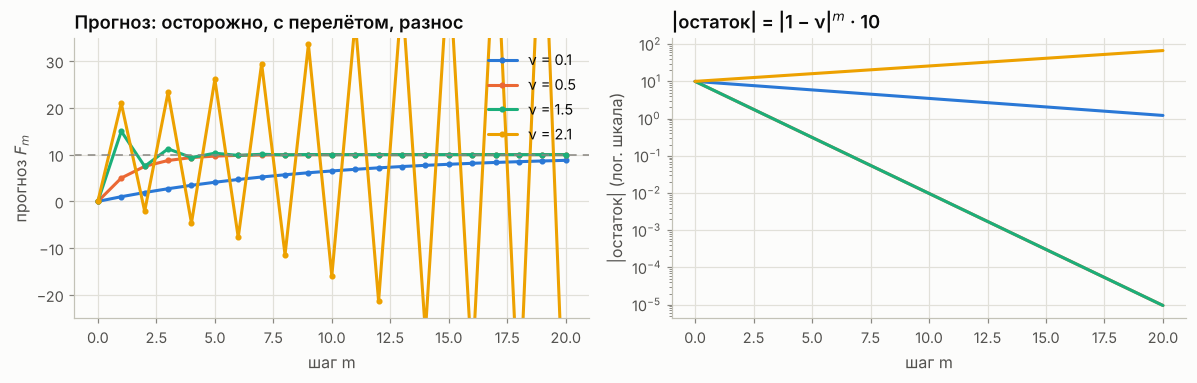

ν = 0.1: шагов до точности 1 % = 44
ν = 0.5: шагов до точности 1 % = 7
ν = 1.5: шагов до точности 1 % = 7


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for nu, color in zip([0.1, 0.5, 1.5, 2.1], style.SERIES):
    F = boost_a_number(10, nu, 20)
    axes[0].plot(F, marker="o", ms=3, color=color, label=f"ν = {nu}")
    axes[1].semilogy(np.abs(10 - F) + 1e-16, color=color, label=f"ν = {nu}")
axes[0].axhline(10, color=style.MUTED, lw=1, ls=(0, (5, 4)))
axes[0].set(xlabel="шаг m", ylabel="прогноз $F_m$", title="Прогноз: осторожно, с перелётом, разнос", ylim=(-25, 35))
axes[1].set(xlabel="шаг m", ylabel="|остаток| (лог. шкала)", title="|остаток| = |1 − ν|$^m$ · 10")
axes[0].legend()
fig.tight_layout()
plt.show()

for nu in (0.1, 0.5, 1.5):
    k = abs(1 - nu)
    print(f"ν = {nu}: шагов до точности 1 % = {int(np.ceil(np.log(0.01) / np.log(k) - 1e-12))}")

## 2. Бустинг вручную: шесть квартир

Площадь $x$ и цена $y$ шести квартир. Поправку делает **пень** — дерево с одним вопросом «площадь ≤ t?»:
в каждой группе он предсказывает средний остаток. Порог выбирается перебором середин между соседями.

In [4]:
x = np.array([30, 40, 50, 60, 70, 80.0])  # площадь, м²
y = np.array([3, 5, 4, 8, 9, 13.0])  # цена, млн


def best_stump(x: np.ndarray, r: np.ndarray):
    """Лучший пень для остатков r: (ошибка, порог, среднее слева, среднее справа)."""
    best = None
    for t in (x[:-1] + x[1:]) / 2:
        left, right = r[x <= t].mean(), r[x > t].mean()
        sse = ((r - np.where(x <= t, left, right)) ** 2).sum()
        if best is None or sse < best[0] - 1e-12:
            best = (sse, t, left, right)
    return best


F = np.full_like(y, y.mean())  # F_0 = 7
r = y - F
print("F_0 =", F[0], " остатки:", r, " сумма квадратов:", (r**2).sum())
print("\nДерево 1: ошибка пня для каждого порога")
for t in (35, 45, 55, 65, 75):
    left, right = r[x <= t].mean(), r[x > t].mean()
    print(f"  порог {t}: слева {left:+.2f}, справа {right:+.2f}, ошибка {((r - np.where(x <= t, left, right)) ** 2).sum():.2f}")

F_0 = 7.0  остатки: [-4. -2. -3.  1.  2.  6.]  сумма квадратов: 70.0

Дерево 1: ошибка пня для каждого порога
  порог 35: слева -4.00, справа +0.80, ошибка 50.80
  порог 45: слева -3.00, справа +1.50, ошибка 43.00
  порог 55: слева -3.00, справа +3.00, ошибка 16.00
  порог 65: слева -2.00, справа +4.00, ошибка 22.00
  порог 75: слева -1.20, справа +6.00, ошибка 26.80


Лучший порог — 55 (ошибка 16). Сделаем шесть деревьев с темпом $\nu = 0.5$ и запомним все модели.

In [5]:
nu = 0.5
F = np.full_like(y, y.mean())
models = [F.copy()]
stumps = []
print(f"дерево 0: сумма квадратов остатков = {((y - F) ** 2).sum():.4f}")
for m in range(1, 7):
    r = y - F  # 1) остатки
    sse, t, left, right = best_stump(x, r)  # 2) пень на остатках
    F = F + nu * np.where(x <= t, left, right)  # 3) обновление
    models.append(F.copy())
    stumps.append((t, left, right))
    print(f"дерево {m}: площадь <= {t:.0f}?  {left:+.3f} / {right:+.3f}   F = {np.round(F, 3)}   сумма квадратов = {((y - F) ** 2).sum():.4f}")

дерево 0: сумма квадратов остатков = 70.0000
дерево 1: площадь <= 55?  -3.000 / +3.000   F = [5.5 5.5 5.5 8.5 8.5 8.5]   сумма квадратов = 29.5000
дерево 2: площадь <= 75?  -0.900 / +4.500   F = [ 5.05  5.05  5.05  8.05  8.05 10.75]   сумма квадратов = 11.2750
дерево 3: площадь <= 65?  -0.800 / +1.600   F = [ 4.65  4.65  4.65  7.65  8.85 11.55]   сумма квадратов = 5.5150
дерево 4: площадь <= 35?  -1.650 / +0.330   F = [ 3.825  4.815  4.815  7.815  9.015 11.715]   сумма квадратов = 3.0647
дерево 5: площадь <= 75?  -0.257 / +1.285   F = [ 3.696  4.686  4.686  7.687  8.886 12.358]   сумма квадратов = 1.5786
дерево 6: площадь <= 55?  -0.356 / +0.356   F = [ 3.518  4.508  4.508  7.865  9.065 12.536]   сумма квадратов = 1.0067


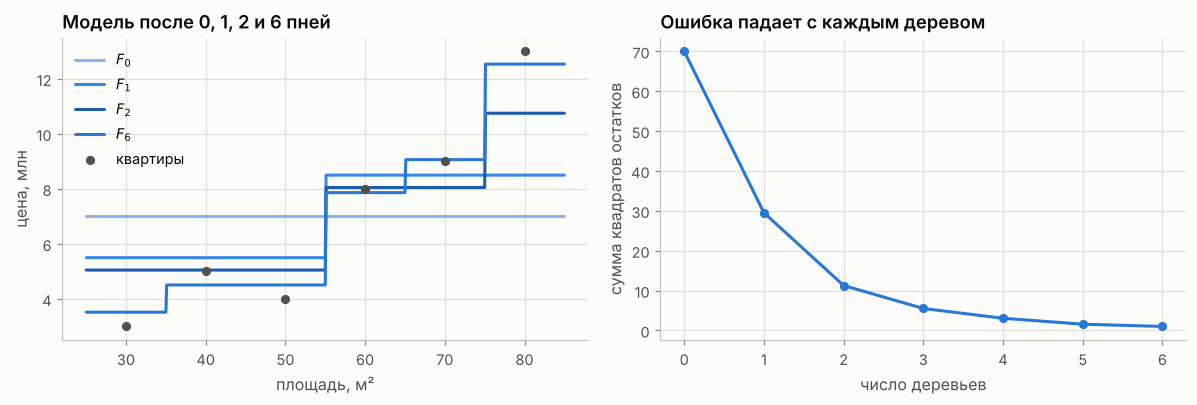

In [6]:
def model_curve(xs: np.ndarray, m: int) -> np.ndarray:
    """F_m на сетке: константа плюс сумма ν·пней."""
    out = np.full_like(xs, y.mean())
    for t, left, right in stumps[:m]:
        out += nu * np.where(xs <= t, left, right)
    return out


xs = np.linspace(25, 85, 601)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for m, color in zip([0, 1, 2, 6], [style.ROLE["model_prev"], style.BLUE_RAMP[6], style.BLUE_RAMP[9], style.BLUE]):
    axes[0].plot(xs, model_curve(xs, m), color=color, label=f"$F_{m}$", lw=2)
axes[0].scatter(x, y, color=style.ROLE["data"], zorder=3, label="квартиры")
axes[0].set(xlabel="площадь, м²", ylabel="цена, млн", title="Модель после 0, 1, 2 и 6 пней")
axes[0].legend()
sses = [((y - Fm) ** 2).sum() for Fm in models]
axes[1].plot(range(len(sses)), sses, marker="o", color=style.BLUE)
axes[1].set(xlabel="число деревьев", ylabel="сумма квадратов остатков", title="Ошибка падает с каждым деревом")
fig.tight_layout()
plt.show()

Проверка: scikit-learn с пнями (`max_depth=1`) даёт те же прогнозы.

In [7]:
from sklearn.ensemble import GradientBoostingRegressor

sk = GradientBoostingRegressor(n_estimators=6, learning_rate=0.5, max_depth=1).fit(x[:, None], y)
print("наш F_6:", np.round(models[-1], 6))
print("sklearn:", np.round(sk.predict(x[:, None]), 6))
print("расхождение:", np.abs(models[-1] - sk.predict(x[:, None])).max())

наш F_6: [ 3.51825  4.50825  4.50825  7.86475  9.06475 12.53575]
sklearn: [ 3.51825  4.50825  4.50825  7.86475  9.06475 12.53575]
расхождение: 0.0


## 3. Слабый ученик и сила суммы

60 точек «волны с трендом» для обучения и 300 новых точек из того же источника для проверки.
Сравним один пень, одно глубокое дерево, бэггинг 50 глубоких деревьев и бустинг 100 пней.

In [8]:
X, yw = datasets.regression_1d(kind="wave", n=60, noise=0.35, seed=7)
Xn, yn = datasets.regression_1d(kind="wave", n=300, noise=0.35, seed=107)

contenders = {
    "пень": RegressionTree(max_depth=1).fit(X, -yw),
    "дерево глубины 8": RegressionTree(max_depth=8).fit(X, -yw),
    "бэггинг 50 деревьев": BaggingTrees(n_estimators=50, max_depth=8, seed=0).fit(X, yw),
    "бустинг 100 пней": GBRegressor(n_estimators=100, learning_rate=0.3, max_depth=1).fit(X, yw),
}
scores = {}
for name, model in contenders.items():
    scores[name] = (mse(yw, model.predict(X)), mse(yn, model.predict(Xn)))
    print(f"{name:20s}  MSE обучение = {scores[name][0]:.4f}   новые данные = {scores[name][1]:.4f}")
print("порог шума σ² =", 0.35**2)

пень                  MSE обучение = 0.2889   новые данные = 0.3546
дерево глубины 8      MSE обучение = 0.0090   новые данные = 0.2320


бэггинг 50 деревьев   MSE обучение = 0.0347   новые данные = 0.1826
бустинг 100 пней      MSE обучение = 0.0895   новые данные = 0.1684
порог шума σ² = 0.12249999999999998


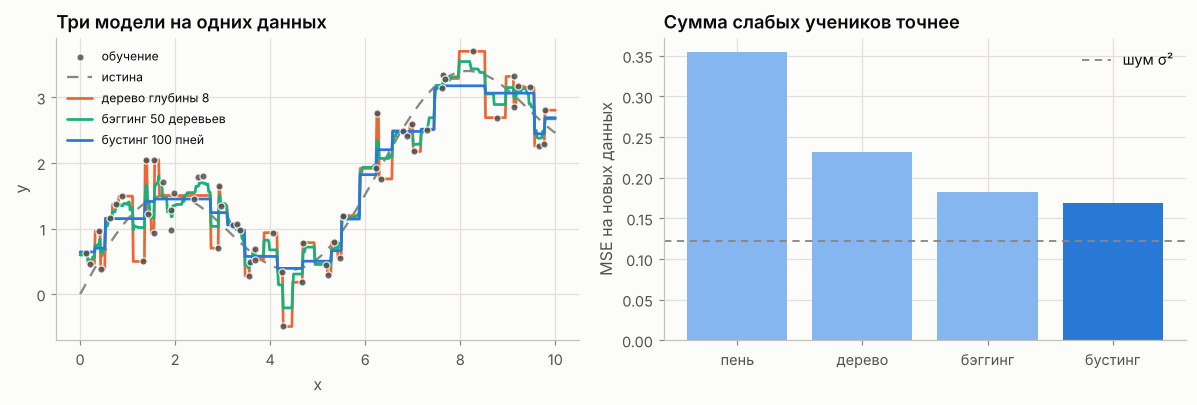

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
grid = np.linspace(0, 10, 600).reshape(-1, 1)
plot_data(axes[0], X, yw, label="обучение")
plot_truth(axes[0], "wave", label="истина")
for (name, model), color in zip(list(contenders.items())[1:], [style.ORANGE, style.AQUA, style.BLUE]):
    axes[0].plot(grid[:, 0], model.predict(grid), color=color, lw=1.8, label=name)
axes[0].set(xlabel="x", ylabel="y", title="Три модели на одних данных")
axes[0].legend(fontsize=8)
names = list(scores)
axes[1].bar(range(4), [scores[n][1] for n in names], color=[style.ROLE["model_prev"]] * 3 + [style.BLUE])
axes[1].axhline(0.35**2, color=style.MUTED, ls=(0, (4, 3)), lw=1.2, label="шум σ²")
axes[1].set_xticks(range(4), ["пень", "дерево", "бэггинг", "бустинг"])
axes[1].set(ylabel="MSE на новых данных", title="Сумма слабых учеников точнее")
axes[1].legend()
fig.tight_layout()
plt.show()

Глубокое дерево почти идеально на обучении, но запомнило шум. Бустинг из самых слабых моделей —
пней — оказывается точнее всех на новых данных.

## 4. Бустинг на 60 точках шаг за шагом

Деревья глубины 2, темп 0.3. Слева — модель до и после первого шага, справа — остатки константы и
первое дерево, которое их приближает.

F0 = среднее y = 1.5555  (проверка: 1.5555)


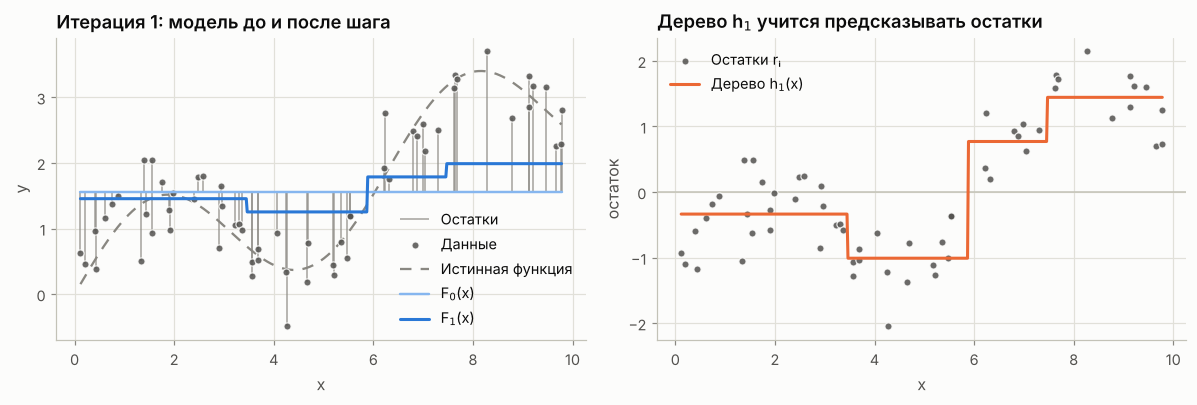

In [10]:
model = GBRegressor(n_estimators=60, learning_rate=0.3, max_depth=2).fit(X, yw)
print(f"F0 = среднее y = {model.init_:.4f}  (проверка: {yw.mean():.4f})")
plot_boosting_step(model, X, yw, m=1, truth_kind="wave")
plt.tight_layout()
plt.show()

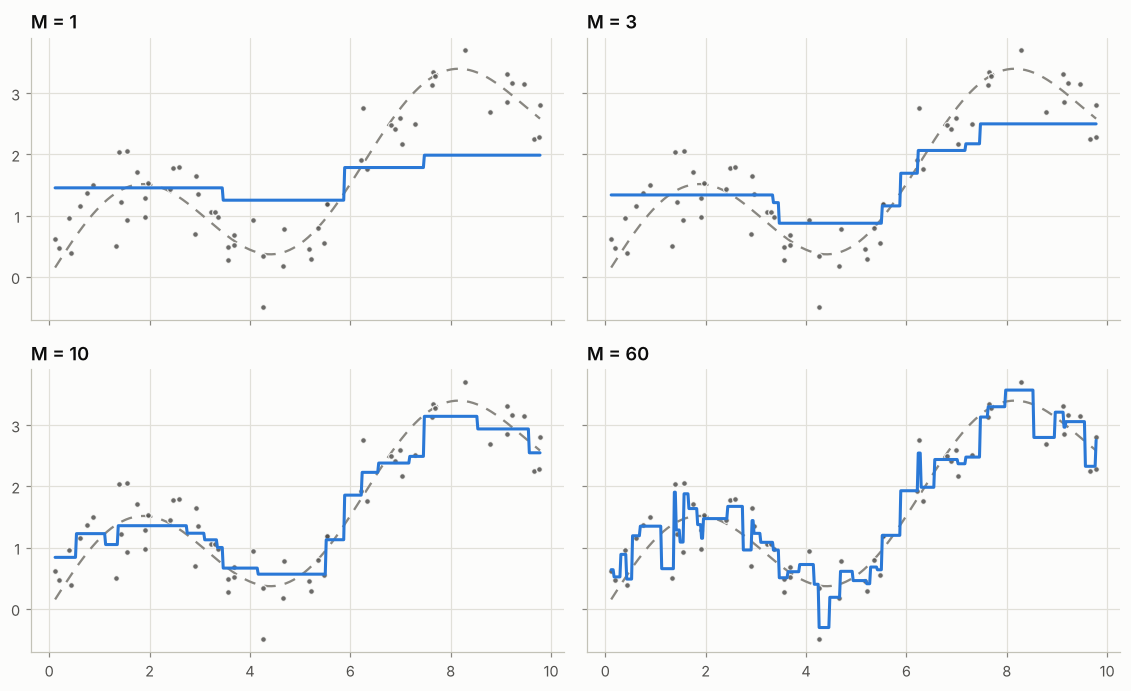

In [11]:
plot_stages(model, X, yw, stages=(1, 3, 10, 60), truth_kind="wave")
plt.show()

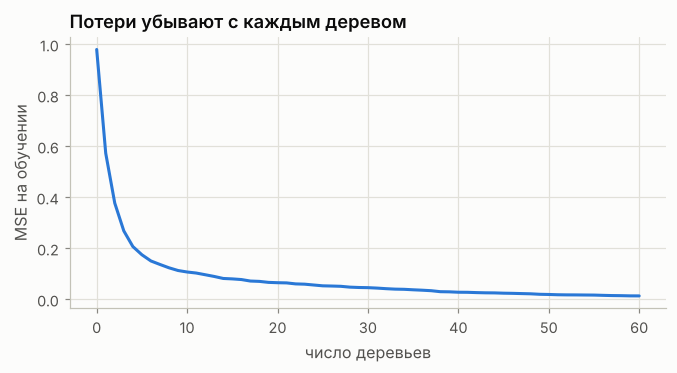

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(np.array(model.history_["train"]) * 2, color=style.BLUE)
ax.set(xlabel="число деревьев", ylabel="MSE на обучении", title="Потери убывают с каждым деревом")
plt.show()

## 5. Почему «градиентный»

Деревья учатся на антиградиенте потерь $-\partial L/\partial F$. Для квадратичных потерь это остаток $y-F$,
для абсолютных — только его знак. Посмотрим на данных с выбросами.

squared : F0 = +0.111; первые псевдо-остатки: [ 0.162 -0.138 -4.817  0.298  0.326  0.358]
absolute: F0 = +0.416; первые псевдо-остатки: [-1. -1. -1. -1.  1.  1.]


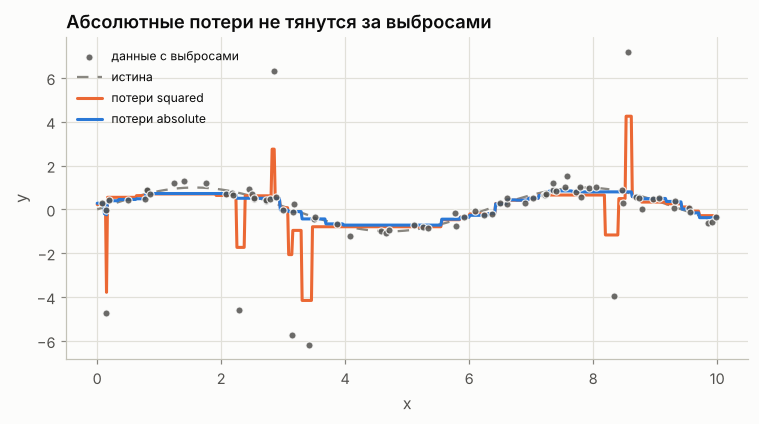

In [13]:
Xo, yo = datasets.regression_1d(kind="sine", n=80, noise=0.2, seed=5, outliers=0.08)
fig, ax = plt.subplots(figsize=(8, 3.8))
plot_data(ax, Xo, yo, label="данные с выбросами")
plot_truth(ax, "sine", label="истина")
for loss, color in [("squared", style.ORANGE), ("absolute", style.BLUE)]:
    gb = GBRegressor(loss=loss, n_estimators=60, learning_rate=0.1, max_depth=2).fit(Xo, yo)
    ax.plot(grid[:, 0], gb.predict(grid), color=color, lw=2, label=f"потери {loss}")
    r0 = -gb.loss_.gradient(yo, np.full_like(yo, gb.init_))
    print(f"{loss:8s}: F0 = {gb.init_:+.3f}; первые псевдо-остатки: {np.round(r0[:6], 3)}")
ax.set(xlabel="x", ylabel="y", title="Абсолютные потери не тянутся за выбросами")
ax.legend(fontsize=8)
plt.show()

## 6. Весь алгоритм в десяти строках

Формула $F_M(x) = F_0 + \nu\sum_m h_m(x)$ с квадратичными потерями — в коде. Деревья берём из `gbcourse`
(дерево обучается на «градиентах» $g = -r$, поэтому передаём `-r`).

In [14]:
def tiny_boosting(X, y, M=60, nu=0.3, depth=2):
    F0 = y.mean()  # строка 1: стартовая константа
    F = np.full_like(y, F0)
    trees = []
    for _ in range(M):  # строка 2: цикл по деревьям
        r = y - F  # строка 3: (псевдо-)остатки
        tree = RegressionTree(max_depth=depth).fit(X, -r)  # строка 4: дерево на остатках
        F = F + nu * tree.predict(X)  # строка 5: шаг
        trees.append(tree)
    return lambda Z: F0 + nu * sum(t.predict(Z) for t in trees)  # строка 6: ответ


predict = tiny_boosting(X, yw)
sk = GradientBoostingRegressor(n_estimators=60, learning_rate=0.3, max_depth=2).fit(X, yw)
print("Наш бустинг в x = 5:   ", predict(np.array([[5.0]]))[0])
print("scikit-learn в x = 5:  ", sk.predict([[5.0]])[0])
print("gbcourse в x = 5:      ", model.predict(np.array([[5.0]]))[0])
print("Макс. расхождение с sklearn на обучении:", np.abs(predict(X) - sk.predict(X)).max())

Наш бустинг в x = 5:    0.46010236105134683
scikit-learn в x = 5:   0.46010236105134666
gbcourse в x = 5:       0.46010236105134666
Макс. расхождение с sklearn на обучении: 1.3322676295501878e-15


Расхождение порядка $10^{-15}$ — это погрешность округления чисел с плавающей точкой. Учебная реализация
делает ровно то же, что scikit-learn, но её код открыт и разобран в курсе: `shared/python/gbcourse/boosting.py`.

## Упражнения

1. Найдите минимальное число шагов, за которое «бустинг одного числа» с $\nu = 0.1$ подойдёт к цели ближе
   чем на 1%. Проверьте ответ формулой $(1-\nu)^m < 0.01$.
2. Посчитайте руками третий пень для шести квартир и сумму квадратов после шага с $\nu = 0.5$ (ответ: 5.515).
3. Обучите `GBRegressor` на волне с `max_depth=1` и `learning_rate=0.3`. Сколько деревьев нужно, чтобы
   потери на обучении стали меньше, чем у модели с `max_depth=2` после 20 деревьев?
4. Повторите сравнение раздела 3 для бустинга 300 пней с темпами 1.0, 0.3 и 0.1. Где ошибка на новых данных меньше?
5. Перепишите `tiny_boosting` для абсолютных потерь: остатки заменяются знаками, а значения листьев — медианами
   остатков. Сравните с квадратичными потерями на данных с выбросами.

<details><summary>Решения</summary>

Запускаемые решения: `python lessons/lesson_1/exercises/solutions.py`.
</details>